In [1]:
import pandas as pd

countries = pd.read_csv(r"C:\Users\chris\Downloads\Datasets\Moral Machine Data\CountriesChangePr.csv\CountriesChangePr.csv")
clusters  = pd.read_csv(r"C:\Users\chris\Downloads\Datasets\Moral Machine Data\country_cluster_map.csv\country_cluster_map.csv")
survey    = pd.read_csv(r"C:\Users\chris\Downloads\Datasets\Moral Machine Data\SharedResponsesSurvey.csv\SharedResponsesSurvey.csv")

print(countries.shape, countries.head())
print(clusters.shape, clusters.head())
print(survey.shape, survey.columns.tolist())

C:\Users\chris\AppData\Local\Temp\ipykernel_23404\3570735459.py:5: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  survey    = pd.read_csv(r"C:\Users\chris\Downloads\Datasets\Moral Machine Data\SharedResponsesSurvey.csv\SharedResponsesSurvey.csv")


(130, 19)   Unnamed: 0  [Omission -> Commission]: Estimates  \
0        AFG                             0.076590   
1        AGO                             0.035095   
2        ALB                             0.047206   
3        AND                             0.061887   
4        ARE                             0.037076   

   [Passengers -> Pedestrians]: Estimates  Law [Illegal -> Legal]: Estimates  \
0                                0.004591                           0.300034   
1                               -0.072331                           0.361608   
2                                0.054628                           0.345108   
3                                0.230754                           0.411267   
4                                0.122503                           0.357704   

   Gender [Male -> Female]: Estimates  Fitness [Large -> Fit]: Estimates  \
0                           -0.007555                           0.190209   
1                            0.035080 

# Moral Machine – Data Exploration

## Datasets loaded
- countries: 130 rows, one per country, with 9 moral preference scores
- clusters: country cluster assignments from original paper
- survey: 11 million individual responses with demographic data

In [4]:
irrelevant_cols = [
    "ExtendedSessionID", "Template", "DescriptionShown",
    "LeftHand", "ResponseID"
]

survey = survey.drop(columns=irrelevant_cols, errors="ignore")

In [ ]:
#Håndtere missing values
print(survey.isnull().sum().sort_values(ascending=False).head(20))

Review_age                 1351805
NonDefaultChoice           1201814
DefaultChoiceIsOmission    1201814
DefaultChoice              1201814
UserCountry3                 41641
Review_gender                   90
CrossingSignal                   0
PedPed                           0
Intervention                     0
ScenarioOrder                    0
Barrier                          0
ScenarioType                     0
AttributeLevel                   0
DiffNumberOFCharacters           0
NumberOfCharacters               0
ScenarioTypeStrict               0
Saved                            0
Review_education                 0
Review_income                    0
Review_political                 0
dtype: int64


In [3]:
# 1. Drop kritiske missing values
# Vi fjerner rader som mangler sentrale variabler for analysen
# (UserCountry3 og Intervention), siden disse er nødvendige.
survey = survey.dropna(subset=["UserCountry3", "Intervention"])

# 2. Håndter ikke-kritiske missing values
# I stedet for å droppe disse radene (som ville fjernet ~1.3M observasjoner),
# fyller vi manglende demografiske verdier:
# - Alder settes til -1 (ukjent)
# - Kjønn settes til "Unknown"
survey["Review_age"] = survey["Review_age"].fillna(-1)
survey["Review_gender"] = survey["Review_gender"].fillna("Unknown")

# 3. Fjern irrelevante kolonner
# Disse kolonnene beskriver kun hvordan valget ble presentert,
# og er ikke relevante for analyse av moralske beslutninger.
survey = survey.drop(columns=[
    "DefaultChoice", 
    "NonDefaultChoice", 
    "DefaultChoiceIsOmission"
], errors="ignore")

In [14]:
#Feature enginering and vectors

# Feature engineering and vectors

# B. Scenario type
survey["is_pedestrian"] = survey["PedPed"]

# C. Difference feature
survey["life_diff"] = survey["NumberOfCharacters"] - survey["DiffNumberOFCharacters"]

# D. Saving more vs. saving less
survey["is_saving_more"] = (survey["life_diff"] > 0).astype(int)

# Quick exploratory analysis
print(survey.groupby("UserCountry3")["Intervention"].mean().head())
print(survey.groupby("is_saving_more")["Intervention"].mean())

UserCountry3
ABW    0.502732
AFG    0.491379
AGO    0.494475
AIA    0.494624
ALA    0.513761
Name: Intervention, dtype: float64
is_saving_more
0    0.498614
1    0.499097
Name: Intervention, dtype: float64


In [15]:
mapping = {
    0: "No signal",
    1: "Green",
    2: "Red"
}

survey["signal_type"] = survey["CrossingSignal"].map(mapping)

print(survey.groupby("signal_type")["Intervention"].mean())

signal_type
Green        0.540255
No signal    0.524946
Red          0.390545
Name: Intervention, dtype: float64


In [17]:
survey["has_signal"] = (survey["CrossingSignal"] > 0).astype(int)

In [10]:
print(survey.groupby("has_signal")["Intervention"].mean())

has_signal
0    0.524946
1    0.459394
Name: Intervention, dtype: float64


In [11]:
country_means = survey.groupby("UserCountry3")["Intervention"].mean().sort_values()

print("Lowest:")
print(country_means.head(5))

print("\nHighest:")
print(country_means.tail(5))

Lowest:
UserCountry3
TGO    0.468085
COK    0.478261
SPM    0.478261
LSO    0.478261
SWZ    0.480000
Name: Intervention, dtype: float64

Highest:
UserCountry3
DMA    0.520000
FSM    0.520000
DJI    0.521739
TKM    0.521739
SLE    0.525000
Name: Intervention, dtype: float64


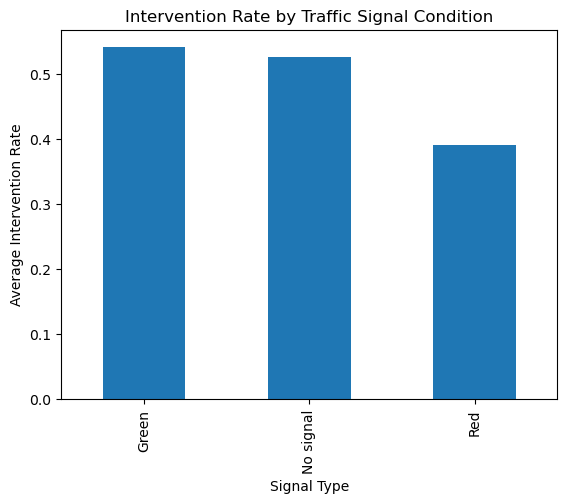

In [18]:
import matplotlib.pyplot as plt

# Beregn gjennomsnitt
signal_means = survey.groupby("signal_type")["Intervention"].mean()

# Plot
signal_means.plot(kind="bar")

plt.title("Intervention Rate by Traffic Signal Condition")
plt.ylabel("Average Intervention Rate")
plt.xlabel("Signal Type")

plt.show()

Figure 1 shows the average intervention rate across different traffic signal conditions. Participants are most likely to intervene when the signal is green, slightly less when there is no signal, and significantly less when the signal is red. This suggests that rule-following plays an important role in moral decision-making.

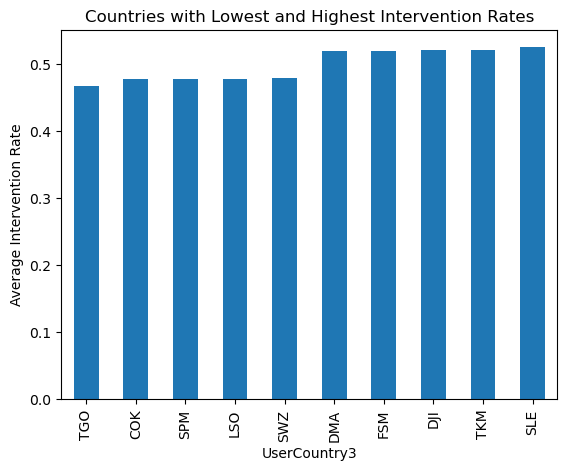

In [19]:
country_means = survey.groupby("UserCountry3")["Intervention"].mean().sort_values()

# Ta kun topp og bunn for å unngå rot
top_bottom = pd.concat([country_means.head(5), country_means.tail(5)])

top_bottom.plot(kind="bar")

plt.title("Countries with Lowest and Highest Intervention Rates")
plt.ylabel("Average Intervention Rate")

plt.show()

Figure 2 illustrates variation across countries. While some differences exist, most countries show intervention rates close to 0.5, indicating relatively similar decision patterns globally.